## task 1

In [33]:
sentences = [
    "I bought a new car.",
    "I purchased an automobile.",
    "Artificial Intelligence is changing healthcare.",
    "Machine learning improves medical diagnosis.",
    "The weather is sunny today.",
    "It is raining outside."
]

In [34]:
def jaccard_similarity(sen1, sen2):
    token1 = set(sen1.lower().split())
    token2 = set(sen2.lower().split())

    intersection = token1.intersection(token2)
    union = token1.union(token2)

    return len(intersection) / len(union)

n = len(sentences)

print("Jaccard Similarity Matrix:")

for i in range(n):
    row = []

    for j in range(n):
        sim = jaccard_similarity(sentences[i], sentences[j])
        row.append(f"{sim:.2f}")

    print("\t".join(row))

Jaccard Similarity Matrix:
1.00	0.12	0.00	0.00	0.00	0.00
0.12	1.00	0.00	0.00	0.00	0.00
0.00	0.00	1.00	0.00	0.11	0.12
0.00	0.00	0.00	1.00	0.00	0.00
0.00	0.00	0.11	0.00	1.00	0.12
0.00	0.00	0.12	0.00	0.12	1.00


In [35]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

vectorizer = CountVectorizer().fit(sentences)
vectors = vectorizer.transform(sentences)

similarity_matrix = cosine_similarity(vectors)

print("Cosine Similarity Matrix:")

for row in similarity_matrix:
    print("\t".join(f"{value:.2f}" for value in row))

Cosine Similarity Matrix:
1.00	0.00	0.00	0.00	0.00	0.00
0.00	1.00	0.00	0.00	0.00	0.00
0.00	0.00	1.00	0.00	0.20	0.22
0.00	0.00	0.00	1.00	0.00	0.00
0.00	0.00	0.20	0.00	1.00	0.22
0.00	0.00	0.22	0.00	0.22	1.00


## task 2

In [1]:
import pandas as pd

df = pd.read_csv("data/BBCNews.csv")

df = df[["descr"]]

df = df.dropna()

df = df.drop_duplicates(subset=["descr"])

sentences = df["descr"].tolist()

print("Number of Articles:", len(sentences))

Number of Articles: 2128


In [37]:
df

,descr
0,chelsea sack mutu chelsea have sacked adrian ...
1,record fails to lift lacklustre meet yelena i...
2,edu describes tunnel fracas arsenals edu has ...
3,ogara revels in ireland victory ireland flyha...
4,unclear future for striker baros liverpool fo...
...,...
2405,gm in crunch talks on fiat future fiat will m...
2406,uk firm faces venezuelan land row venezuelan ...
2407,winndixie files for bankruptcy us supermarket...
2408,yangtze electrics profits double yangtze elec...


In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(stop_words="english")

tfidf_vectors = vectorizer.fit_transform(sentences)

print(tfidf_vectors.shape)

(2128, 31219)


In [39]:
query_index = 0

query = sentences[query_index]
query_vector = vectorizer.transform([query])
print(query)

chelsea sack mutu  chelsea have sacked adrian mutu after he failed a drugs test  the yearold tested positive for a banned substance  which he later denied was cocaine  in october chelsea have decided to write off a possible transfer fee for mutu a m signing from parma last season who may face a twoyear suspension a statement from chelsea explaining the decision readwe want to make clear that chelsea has a zero tolerance policy towards drugs mutu scored six goals in his first five games after arriving at stamford bridge but his form went into decline and he was frozen out by coach jose mourinho chelseas statement added this applies to both performanceenhancing drugs or socalled recreational drugs they have no place at our club or in sport in coming to a decision on this case chelsea believed the clubs social responsibility to its fans players employees and other stakeholders in football regarding drugs was more important than the major financial considerations to the company any player 

In [40]:
from sklearn.metrics.pairwise import cosine_similarity

tfidf_scores = cosine_similarity(query_vector, tfidf_vectors).flatten()
tfidf_scores[query_index] = -1
top_10_query_results = tfidf_scores.argsort()[-10:][::-1]

In [41]:
print("Top 10 using TF-IDF\n")

for idx in top_10_query_results:

    print("="*100)

    print(f"TF-IDF Score: {tfidf_scores[idx]:.4f}")

    print(sentences[idx])

Top 10 using TF-IDF

TF-IDF Score: 0.4877
wenger offers mutu hope  arsenal boss arsene wenger would consider signing adrian mutu once the striker has served his drugs ban  mutu was sacked by chelsea on friday after testing positive for cocaine  a move wenger has backed but he said i dont even wonder if that could happen because i think he will be suspended for a long period but once he has served his suspension he has the right again to start from zero i would then meet the player and see what he tells me mutu faces a ban of between six months and two years when the football association decides on his punishment chelsea decided to act before his case was heard and sacked the striker on grounds of gross misconduct after it was revealed that he had failed a drug test  but mutu has hit out at the clubs decision saying chelsea have destroyed me he told the sunday mirror i dont know what im going to do i am shocked and surprised by their decision i didnt expect them to pay me while i was su

In [42]:
from sentence_transformers import SentenceTransformer
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [43]:
query_emb = model.encode([query])

candidate_articles = [sentences[i] for i in top_10_query_results]

candidate_embs = model.encode(candidate_articles)

In [44]:
sbert_sim_scores = cosine_similarity(
    query_emb,
    candidate_embs
).flatten()

In [45]:
top_5_local_indices = sbert_sim_scores.argsort()[-5:][::-1]

In [46]:
print("Re-ranking results using SBERT:\n")

for local_idx in top_5_local_indices:

    original_idx = top_10_query_results[local_idx]

    score = sbert_sim_scores[local_idx]

    print("="*100)

    print(f"SBERT Score: {score:.4f} (Original Index: {original_idx})")

    print(f"Article: {sentences[original_idx]}")

Re-ranking results using SBERT:

SBERT Score: 0.8109 (Original Index: 1335)
Article: wenger offers mutu hope  arsenal boss arsene wenger would consider signing adrian mutu once the striker has served his drugs ban  mutu was sacked by chelsea on friday after testing positive for cocaine  a move wenger has backed but he said i dont even wonder if that could happen because i think he will be suspended for a long period but once he has served his suspension he has the right again to start from zero i would then meet the player and see what he tells me mutu faces a ban of between six months and two years when the football association decides on his punishment chelsea decided to act before his case was heard and sacked the striker on grounds of gross misconduct after it was revealed that he had failed a drug test  but mutu has hit out at the clubs decision saying chelsea have destroyed me he told the sunday mirror i dont know what im going to do i am shocked and surprised by their decision i

## task 3

In [ ]:
import pandas as pd

df = pd.read_csv("data/customer_support_tickets.csv")

df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [88]:
df["text"] = (
    df["Ticket Subject"].fillna("").astype(str)
    + ". "
    + df["Ticket Description"].fillna("").astype(str)
)

df[["Ticket Subject", "Ticket Description", "text"]].head()

,Ticket Subject,Ticket Description,text
0,Product setup,I'm having an issue with the {product_purchase...,Product setup. I'm having an issue with the {p...
1,Peripheral compatibility,I'm having an issue with the {product_purchase...,Peripheral compatibility. I'm having an issue ...
2,Network problem,I'm facing a problem with my {product_purchase...,Network problem. I'm facing a problem with my ...
3,Account access,I'm having an issue with the {product_purchase...,Account access. I'm having an issue with the {...
4,Data loss,I'm having an issue with the {product_purchase...,Data loss. I'm having an issue with the {produ...


In [85]:
model = SentenceTransformer("all-MiniLM-L6-v2")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [89]:
embeddings = model.encode(
    df["text"].tolist(),
    convert_to_tensor=True
)

In [90]:
from sklearn.metrics.pairwise import cosine_similarity

def semantic_search(query, top_k=5):

    query_embedding = model.encode([query])

    similarities = cosine_similarity(
        query_embedding,
        embeddings
    )[0]

    top_indices = similarities.argsort()[::-1][:top_k]

    results = df.iloc[top_indices][[
        "text",

    ]].copy()

    results["Similarity Score"] = similarities[top_indices]

    return results.sort_values(
        by="Similarity Score",
        ascending=False
    )

In [91]:
query = "I forgot my password and cannot log in."

results = semantic_search(query)

results

,text,Similarity Score
3495,Delivery problem. I've forgotten my password f...,0.706473
1604,Account access. I've forgotten my password for...,0.692984
7740,Account access. I've forgotten my password for...,0.689086
3573,Product recommendation. I've forgotten my pass...,0.682102
1754,Product setup. I've forgotten my password for ...,0.680981


In [92]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(stop_words="english")

tfidf_matrix = tfidf.fit_transform(df["text"])

In [93]:
def tfidf_search(query, top_k=5):

    query_vector = tfidf.transform([query])

    similarities = cosine_similarity(
        query_vector,
        tfidf_matrix
    )[0]

    top_indices = similarities.argsort()[::-1][:top_k]

    results = df.iloc[top_indices][[
        "text",
    ]].copy()

    results["Similarity Score"] = similarities[top_indices]

    return results.sort_values(
        by="Similarity Score",
        ascending=False
    )

In [94]:
query = "How can I recover my account?"

semantic_results = semantic_search(query)

print("Semantic Search")
display(semantic_results)


Semantic Search


,text,Similarity Score
1604,Account access. I've forgotten my password for...,0.683315
1815,Data loss. I've forgotten my password for my {...,0.677642
7740,Account access. I've forgotten my password for...,0.669442
7518,Data loss. I've forgotten my password for my {...,0.669345
1806,Account access. I've forgotten my password for...,0.667448


In [95]:
tfidf_results = tfidf_search(query)

print("TF-IDF Search")
display(tfidf_results)

TF-IDF Search


,text,Similarity Score
1980,Delivery problem. I've forgotten my password f...,0.532609
1547,Delivery problem. I've forgotten my password f...,0.525115
167,Delivery problem. I've forgotten my password f...,0.513091
2345,Battery life. I've forgotten my password for m...,0.512932
3573,Product recommendation. I've forgotten my pass...,0.510446


## task 4

In [ ]:
import pandas as pd

df = pd.read_csv("data/BBCNews.csv")

df = df.dropna()

df = df.drop_duplicates()
    
df = df.drop(columns=["Unnamed: 0"])

print(df.shape)
print(df.columns)

df.head()


(2410, 2)
Index(['descr', 'tags'], dtype='object')


,descr,tags
0,chelsea sack mutu chelsea have sacked adrian ...,"sports, stamford bridge, football association,..."
1,record fails to lift lacklustre meet yelena i...,"sports, madrid, birmingham, france, scotland, ..."
2,edu describes tunnel fracas arsenals edu has ...,"sports, derby, brazil, tunnel fracasedu, food,..."
3,ogara revels in ireland victory ireland flyha...,"sports, bbc, united kingdom, ireland, brian o'..."
4,unclear future for striker baros liverpool fo...,"sports, liverpool, daily sport, millennium sta..."


In [7]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer("all-MiniLM-L6-v2")

embeddings = model.encode(
    df["descr"].tolist(),
    show_progress_bar=True
)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/76 [00:00<?, ?it/s]

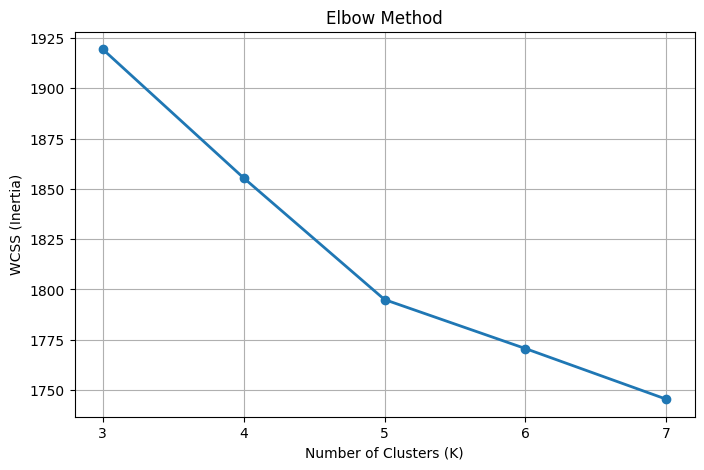

In [8]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

elbow = []

K = [3, 4, 5, 6, 7] 

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(embeddings)
    elbow.append(kmeans.inertia_)

plt.figure(figsize=(8,5))

plt.plot(K, elbow, marker='o', linewidth=2)

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS (Inertia)")

plt.xticks(K)
plt.grid(True)

plt.show()

In [9]:
from sklearn.metrics import silhouette_score, davies_bouldin_score

for k in [3, 4, 5, 6, 7]:
    kmeans = KMeans(n_clusters=k, random_state=42)

    labels = kmeans.fit_predict(embeddings)

    sil = silhouette_score(embeddings, labels)
    db = davies_bouldin_score(embeddings, labels)

    print(f"K = {k}")
    print(f"Silhouette Score = {sil:.4f}")
    print(f"Davies-Bouldin Index = {db:.4f}")
    print("-"*40)

K = 3
Silhouette Score = 0.0515
Davies-Bouldin Index = 4.2005
----------------------------------------
K = 4
Silhouette Score = 0.0550
Davies-Bouldin Index = 3.9742
----------------------------------------
K = 5
Silhouette Score = 0.0656
Davies-Bouldin Index = 3.4664
----------------------------------------
K = 6
Silhouette Score = 0.0638
Davies-Bouldin Index = 3.4599
----------------------------------------
K = 7
Silhouette Score = 0.0631
Davies-Bouldin Index = 3.5691
----------------------------------------
